Cell 1: Imports and data loading (shared across all figures)

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

signals = pd.read_csv("FAERS_DDI_SIGNALS.csv")
print("SIGNALS:", signals.columns.tolist())
print(signals.shape)

ror_all = pd.read_csv("FAERS_DDI_ROR_ALL.csv")
print("\nROR_ALL:", ror_all.columns.tolist())
print(ror_all.shape)

hc = pd.read_csv("FAERS_DDI_SIGNALS_HIGH_CONFIDENCE.csv")
print("\nHIGH_CONF:", hc.columns.tolist())
print(hc.shape)

atc = pd.read_csv("drug_atc_mapping.csv")
print("\nATC:", atc.columns.tolist())
print(atc.shape)

# Load all data
hc = pd.read_csv("FAERS_DDI_SIGNALS_HIGH_CONFIDENCE.csv")
ror_all = pd.read_csv("FAERS_DDI_ROR_ALL.csv")
atc = pd.read_csv("drug_atc_mapping.csv")

# Split PAIR into DRUG_A and DRUG_B for all datasets
for df in [hc, ror_all]:
    split = df['PAIR'].str.split(' \\+ ', expand=True, n=1)
    df['DRUG_A'] = split[0]
    df['DRUG_B'] = split[1]

# ATC lookup
atc_lookup = dict(zip(atc['DRUG'], atc['RISK_CLASS']))

# Map classes onto high-confidence signals
hc['CLASS_A'] = hc['DRUG_A'].map(atc_lookup).fillna('Unclassified')
hc['CLASS_B'] = hc['DRUG_B'].map(atc_lookup).fillna('Unclassified')

# Map classes onto all ROR pairs
ror_all['CLASS_A'] = ror_all['DRUG_A'].map(atc_lookup).fillna('Unclassified')
ror_all['CLASS_B'] = ror_all['DRUG_B'].map(atc_lookup).fillna('Unclassified')

# Compute PCT_SERIOUS for ror_all (not pre-computed like hc)
ror_all['PCT_SERIOUS'] = (ror_all['A_SERIOUS_EXPOSED'] / ror_all['N_EXPOSED'] * 100)

print("Data loaded successfully")
print(f"  High-confidence signals: {len(hc)}")
print(f"  All ROR pairs: {len(ror_all)}")
print(f"  ATC mappings: {len(atc)}")

SIGNALS: ['PAIR', 'N_EXPOSED', 'A_SERIOUS_EXPOSED', 'B_NONSERIOUS_EXPOSED', 'ROR', 'CI_LOWER', 'CI_UPPER', 'CHI2', 'P_VALUE', 'P_VALUE_RANK', 'P_VALUE_FDR', 'SIGNAL']
(52434, 12)

ROR_ALL: ['PAIR', 'N_EXPOSED', 'A_SERIOUS_EXPOSED', 'B_NONSERIOUS_EXPOSED', 'ROR', 'CI_LOWER', 'CI_UPPER', 'CHI2', 'P_VALUE', 'P_VALUE_RANK', 'P_VALUE_FDR', 'SIGNAL']
(226256, 12)

HIGH_CONF: ['PAIR', 'N_EXPOSED', 'A_SERIOUS_EXPOSED', 'B_NONSERIOUS_EXPOSED', 'ROR', 'CI_LOWER', 'CI_UPPER', 'CHI2', 'P_VALUE', 'P_VALUE_RANK', 'P_VALUE_FDR', 'SIGNAL', 'PCT_SERIOUS', 'FLAG_HIGH_SERIOUS_RATE', 'CI_RATIO', 'FLAG_WIDE_CI', 'FLAG_SMALL_N_HIGH_ROR', 'FLAG_POSSIBLE_VETERINARY', 'FLAG_SAME_DRUG', 'QUALITY_FLAGS']
(5501, 20)

ATC: ['DRUG', 'ATC_CODE_FULL', 'ATC_L1_CODE', 'ATC_L1_NAME', 'ATC_L2_CODE', 'ATC_L2_NAME', 'ATC_L3_CODE', 'ATC_L3_NAME', 'NUM_ATC_CLASSES', 'RISK_CLASS']
(682, 10)
Data loaded successfully
  High-confidence signals: 5501
  All ROR pairs: 226256
  ATC mappings: 682


Cell 2: Figure 1 — Serious Event Rate by ATC Class

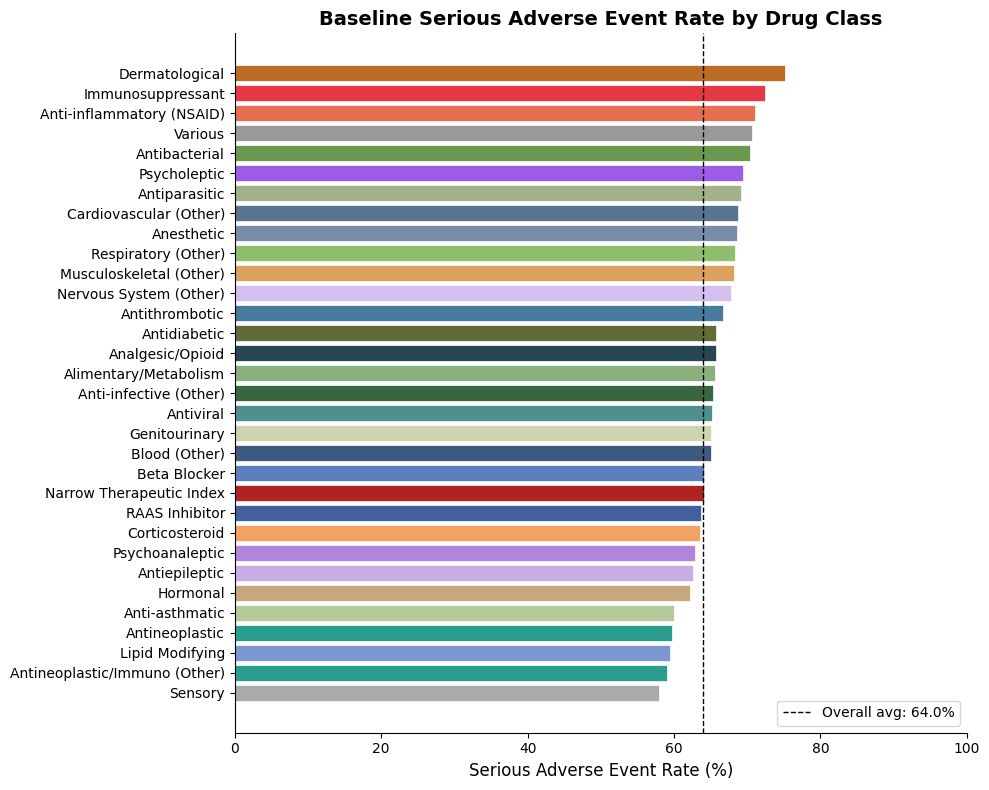

Saved: fig1_serious_rate_by_class.png


In [22]:
# ============================================================
# FIGURE 1: Serious Event Rate by ATC Drug Class
# ============================================================

# For each drug, get its class and compute average serious rate across all pairs it appears in
drug_serious_a = ror_all.groupby('CLASS_A').agg(
    total_exposed=('N_EXPOSED', 'sum'),
    total_serious=('A_SERIOUS_EXPOSED', 'sum')
).rename_axis('CLASS')

drug_serious_b = ror_all.groupby('CLASS_B').agg(
    total_exposed=('N_EXPOSED', 'sum'),
    total_serious=('A_SERIOUS_EXPOSED', 'sum')
).rename_axis('CLASS')

# Combine A and B sides
class_rates = (drug_serious_a.add(drug_serious_b, fill_value=0))
class_rates['serious_rate'] = class_rates['total_serious'] / class_rates['total_exposed'] * 100
class_rates = class_rates.sort_values('serious_rate', ascending=True)

# Drop Unclassified for cleaner plot
class_rates = class_rates.drop('Unclassified', errors='ignore')

# Color map
COLOR_MAP_HEX = {
    'Immunosuppressant': '#E63946', 'Anti-inflammatory (NSAID)': '#E76F51',
    'Corticosteroid': '#F4A261', 'Analgesic/Opioid': '#264653',
    'Antineoplastic': '#2A9D8F', 'Antithrombotic': '#457B9D',
    'Alimentary/Metabolism': '#8AB17D', 'Antibacterial': '#6A994E',
    'Anti-infective (Other)': '#386641', 'Antiviral': '#4D908E',
    'Respiratory (Other)': '#90BE6D', 'Anti-asthmatic': '#B5C99A',
    'Cardiovascular (Other)': '#577590', 'RAAS Inhibitor': '#4361A0',
    'Beta Blocker': '#5C7FBF', 'Lipid Modifying': '#7B97D4',
    'Psycholeptic': '#9B5DE5', 'Psychoanaleptic': '#B185DB',
    'Antiepileptic': '#C9ADE5', 'Nervous System (Other)': '#D4BFEF',
    'Dermatological': '#BC6C25', 'Musculoskeletal (Other)': '#DDA15E',
    'Antidiabetic': '#606C38', 'Genitourinary': '#CCD5AE',
    'Blood (Other)': '#3D5A80', 'Anesthetic': '#778DA9',
    'Antiparasitic': '#A3B18A', 'Narrow Therapeutic Index': '#B22222',
    'Hormonal': '#C7A87D', 'Various': '#999999',
    'Antineoplastic/Immuno (Other)': '#2A9D8F', 'Sensory': '#AAAAAA',
}
bar_colors = [COLOR_MAP_HEX.get(c, '#999999') for c in class_rates.index]

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(class_rates.index, class_rates['serious_rate'], color=bar_colors, edgecolor='white', linewidth=0.5)

# Add overall average line
overall_rate = ror_all['A_SERIOUS_EXPOSED'].sum() / ror_all['N_EXPOSED'].sum() * 100
ax.axvline(overall_rate, color='black', linestyle='--', linewidth=1, label=f'Overall avg: {overall_rate:.1f}%')

ax.set_xlabel('Serious Adverse Event Rate (%)', fontsize=12)
ax.set_title('Baseline Serious Adverse Event Rate by Drug Class', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlim(0, 100)
sns.despine()
plt.tight_layout()
plt.savefig('fig1_serious_rate_by_class.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: fig1_serious_rate_by_class.png")

Cell 3: Figure 2 — Cross-Class Risk Matrix Heatmap

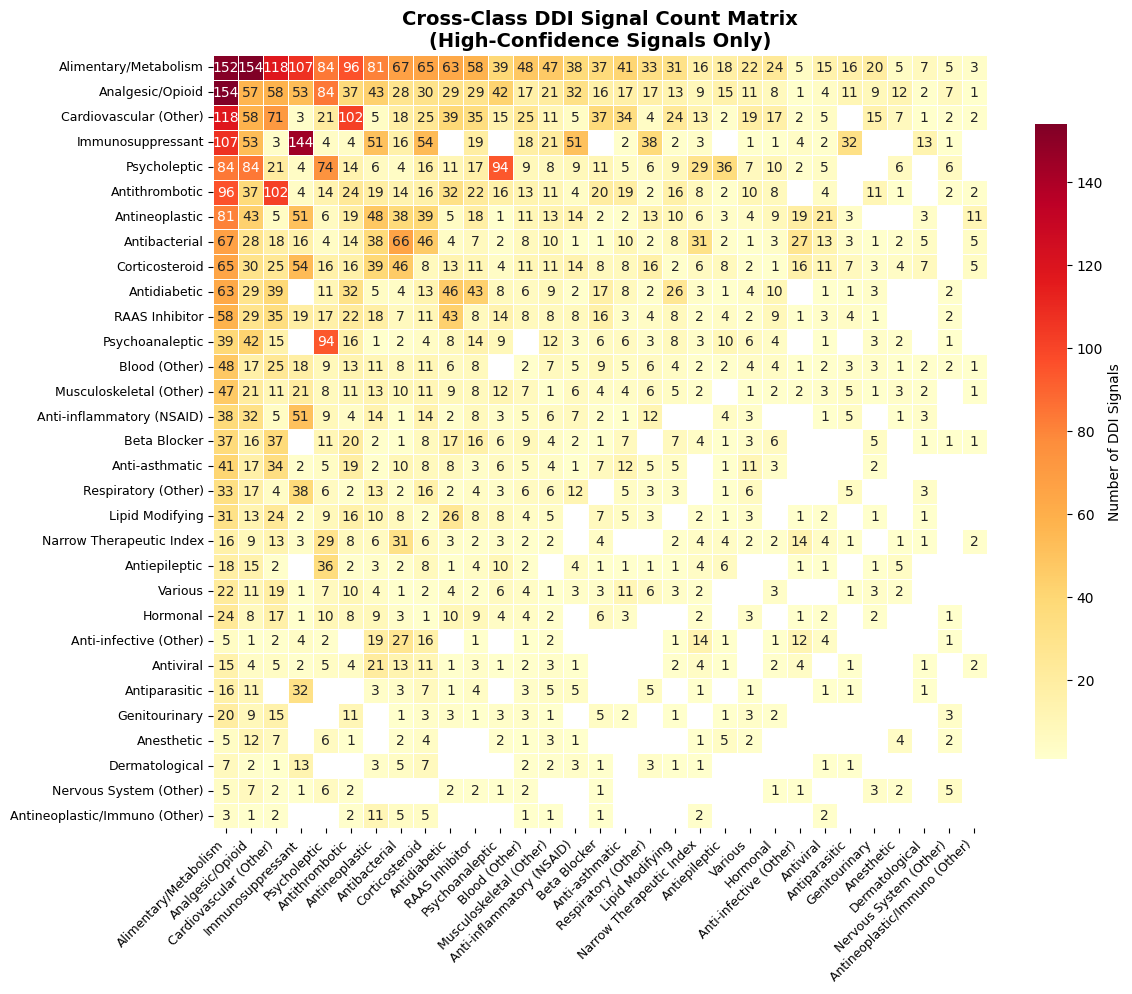

Saved: fig2_cross_class_heatmap.png


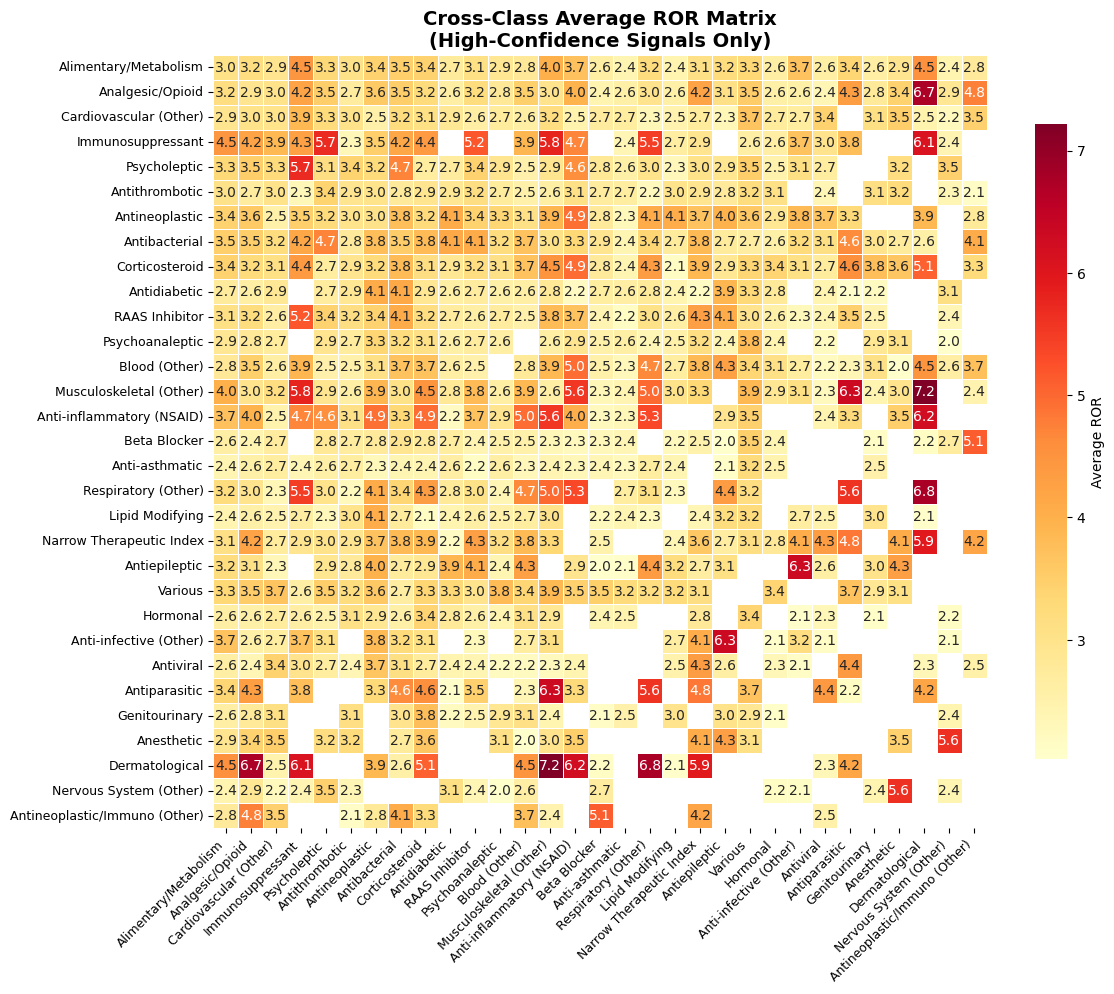

Saved: fig2b_cross_class_ror_heatmap.png


In [23]:
# ============================================================
# FIGURE 2: Cross-Class DDI Risk Matrix
# ============================================================

# Use high-confidence signals only
# Create sorted class pair and compute average ROR
hc['class_pair'] = hc.apply(lambda r: tuple(sorted([r['CLASS_A'], r['CLASS_B']])), axis=1)

# Count signals and average ROR per class pair
class_matrix_data = hc.groupby('class_pair').agg(
    signal_count=('ROR', 'count'),
    avg_ror=('ROR', 'mean')
).reset_index()

class_matrix_data['CLASS_1'] = class_matrix_data['class_pair'].str[0]
class_matrix_data['CLASS_2'] = class_matrix_data['class_pair'].str[1]

# Get top classes by total signal involvement
class_involvement = pd.concat([hc['CLASS_A'], hc['CLASS_B']]).value_counts()
top_classes = class_involvement[class_involvement >= 20].index.tolist()
top_classes = [c for c in top_classes if c != 'Unclassified']

# Build matrix — signal count
matrix_count = pd.DataFrame(0, index=top_classes, columns=top_classes, dtype=float)
matrix_ror = pd.DataFrame(0.0, index=top_classes, columns=top_classes)

for _, row in class_matrix_data.iterrows():
    c1, c2 = row['CLASS_1'], row['CLASS_2']
    if c1 in top_classes and c2 in top_classes:
        matrix_count.loc[c1, c2] = row['signal_count']
        matrix_count.loc[c2, c1] = row['signal_count']
        matrix_ror.loc[c1, c2] = row['avg_ror']
        matrix_ror.loc[c2, c1] = row['avg_ror']

# Replace 0s with NaN for cleaner heatmap
matrix_count_display = matrix_count.replace(0, np.nan)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(matrix_count_display, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, linecolor='white', square=True,
            cbar_kws={'label': 'Number of DDI Signals', 'shrink': 0.8},
            ax=ax, mask=matrix_count_display.isna())

ax.set_title('Cross-Class DDI Signal Count Matrix\n(High-Confidence Signals Only)',
             fontsize=14, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('fig2_cross_class_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: fig2_cross_class_heatmap.png")

# Also make average ROR version
matrix_ror_display = matrix_ror.replace(0, np.nan)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(matrix_ror_display, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, linecolor='white', square=True,
            cbar_kws={'label': 'Average ROR', 'shrink': 0.8},
            ax=ax, mask=matrix_ror_display.isna())

ax.set_title('Cross-Class Average ROR Matrix\n(High-Confidence Signals Only)',
             fontsize=14, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('fig2b_cross_class_ror_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: fig2b_cross_class_ror_heatmap.png")

Cell 5: Figure 4 — Same-Class vs Cross-Class Polypharmacy

Same-Class vs Cross-Class Summary:
                  count  mean_ror  median_ror  mean_n  mean_serious_pct
interaction_type                                                       
Cross-class        4636      3.28        2.79  218.55             75.43
Same-class          765      3.27        2.82  238.23             75.43



/var/folders/5j/6ll410dd2p50x_mj8rswpbdw0000gn/T/ipykernel_20220/930172528.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot([cross_ror, same_ror], labels=['Cross-class', 'Same-class'],
/var/folders/5j/6ll410dd2p50x_mj8rswpbdw0000gn/T/ipykernel_20220/930172528.py:54: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[2].boxplot([cross_pct, same_pct], labels=['Cross-class', 'Same-class'],


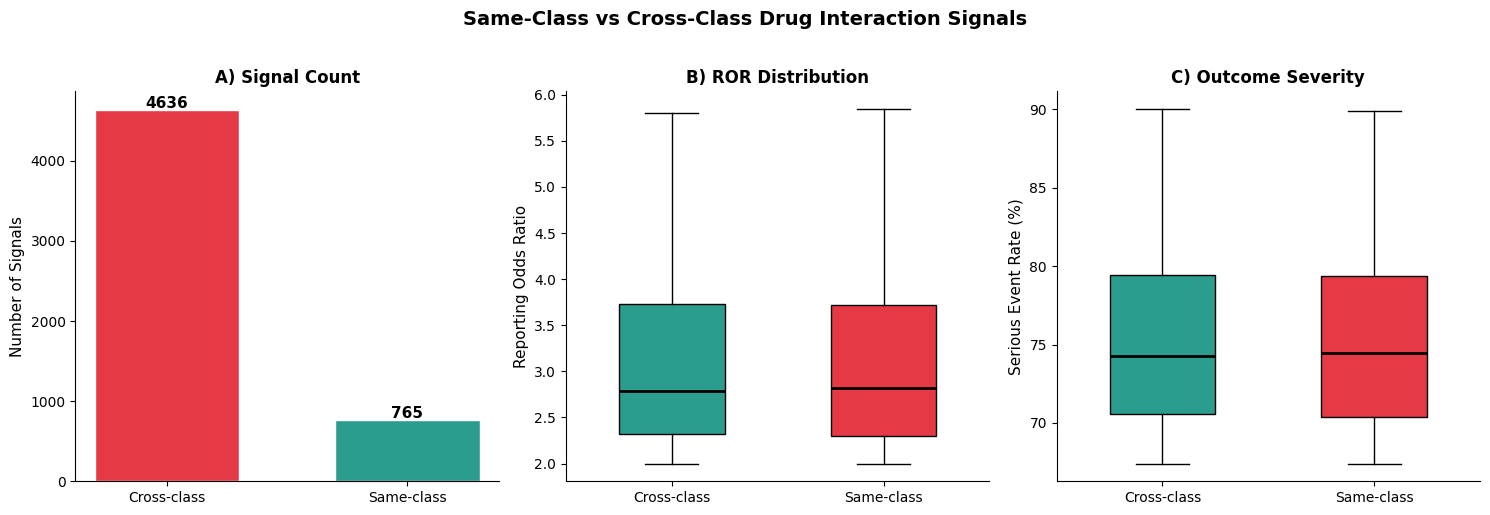

Saved: fig4_same_vs_cross_class.png


In [24]:
# ============================================================
# FIGURE 4: Same-Class vs Cross-Class Polypharmacy Risk
# ============================================================

# Classify each high-confidence signal as same-class or cross-class
hc['interaction_type'] = np.where(hc['CLASS_A'] == hc['CLASS_B'], 'Same-class', 'Cross-class')

# Exclude Unclassified pairs
hc_classified = hc[(hc['CLASS_A'] != 'Unclassified') & (hc['CLASS_B'] != 'Unclassified')]

# Summary statistics
comparison = hc_classified.groupby('interaction_type').agg(
    count=('ROR', 'count'),
    mean_ror=('ROR', 'mean'),
    median_ror=('ROR', 'median'),
    mean_n=('N_EXPOSED', 'mean'),
    mean_serious_pct=('PCT_SERIOUS', 'mean')
).round(2)

print("Same-Class vs Cross-Class Summary:")
print(comparison)
print()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Panel A: Count comparison
counts = hc_classified['interaction_type'].value_counts()
colors_bar = ['#E63946', '#2A9D8F']
axes[0].bar(counts.index, counts.values, color=colors_bar, edgecolor='white', width=0.6)
axes[0].set_ylabel('Number of Signals', fontsize=11)
axes[0].set_title('A) Signal Count', fontsize=12, fontweight='bold')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontsize=11, fontweight='bold')
sns.despine(ax=axes[0])

# Panel B: ROR distribution
same_ror = hc_classified[hc_classified['interaction_type'] == 'Same-class']['ROR']
cross_ror = hc_classified[hc_classified['interaction_type'] == 'Cross-class']['ROR']

bp = axes[1].boxplot([cross_ror, same_ror], labels=['Cross-class', 'Same-class'],
                      patch_artist=True, widths=0.5,
                      medianprops=dict(color='black', linewidth=2),
                      showfliers=False)
bp['boxes'][0].set_facecolor('#2A9D8F')
bp['boxes'][1].set_facecolor('#E63946')
axes[1].set_ylabel('Reporting Odds Ratio', fontsize=11)
axes[1].set_title('B) ROR Distribution', fontsize=12, fontweight='bold')
sns.despine(ax=axes[1])

# Panel C: Serious event rate
same_pct = hc_classified[hc_classified['interaction_type'] == 'Same-class']['PCT_SERIOUS']
cross_pct = hc_classified[hc_classified['interaction_type'] == 'Cross-class']['PCT_SERIOUS']

bp2 = axes[2].boxplot([cross_pct, same_pct], labels=['Cross-class', 'Same-class'],
                       patch_artist=True, widths=0.5,
                       medianprops=dict(color='black', linewidth=2),
                       showfliers=False)
bp2['boxes'][0].set_facecolor('#2A9D8F')
bp2['boxes'][1].set_facecolor('#E63946')
axes[2].set_ylabel('Serious Event Rate (%)', fontsize=11)
axes[2].set_title('C) Outcome Severity', fontsize=12, fontweight='bold')
sns.despine(ax=axes[2])

plt.suptitle('Same-Class vs Cross-Class Drug Interaction Signals', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig4_same_vs_cross_class.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: fig4_same_vs_cross_class.png")

Cell 6: Cropped Heatmap

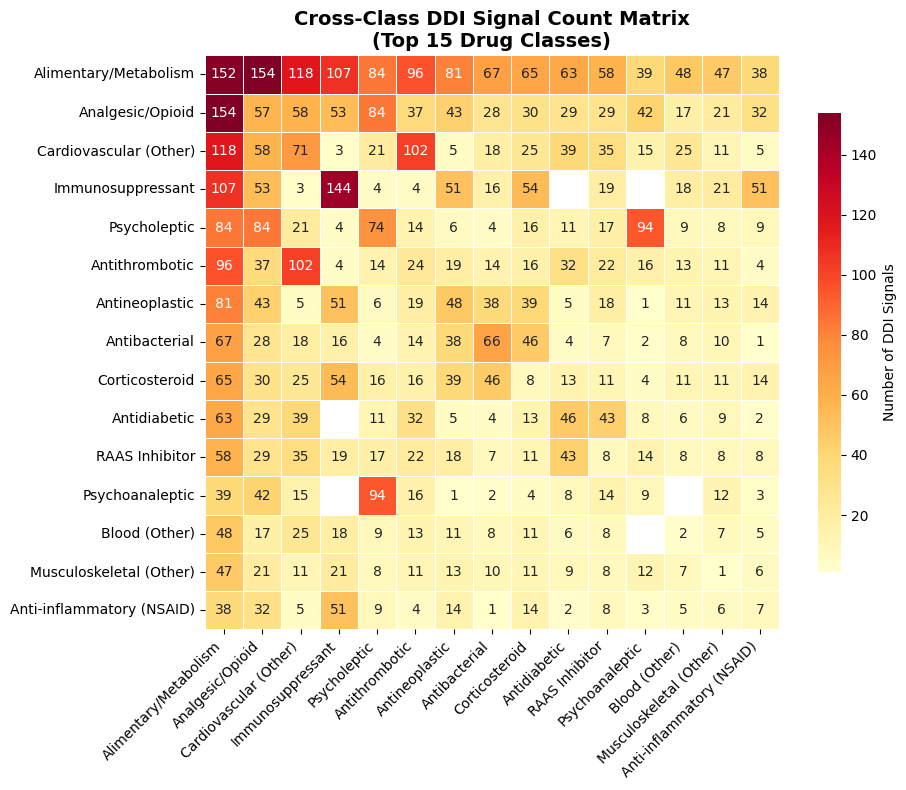

Saved: fig2c_cross_class_heatmap_top15.png


In [ ]:
# ============================================================
# FIGURE 2c: Cross-Class Heatmap — Top 15 Classes Only
# ============================================================

# Get top 15 classes by signal involvement
class_involvement = pd.concat([hc['CLASS_A'], hc['CLASS_B']]).value_counts()
top15 = [c for c in class_involvement.head(16).index if c != 'Unclassified'][:15]

# Build matrix
matrix_15 = pd.DataFrame(0, index=top15, columns=top15, dtype=float)

for _, row in hc.iterrows():
    c1, c2 = row['CLASS_A'], row['CLASS_B']
    if c1 in top15 and c2 in top15:
        matrix_15.loc[c1, c2] += 1
        if c1 != c2:
            matrix_15.loc[c2, c1] += 1

matrix_15_display = matrix_15.replace(0, np.nan)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(matrix_15_display, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, linecolor='white', square=True,
            cbar_kws={'label': 'Number of DDI Signals', 'shrink': 0.8},
            ax=ax, mask=matrix_15_display.isna(), annot_kws={'size': 10})

ax.set_title('Cross-Class DDI Signal Count Matrix\n(Top 15 Drug Classes)',
             fontsize=14, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
plt.tight_layout()
plt.savefig('fig2c_cross_class_heatmap_top15.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: fig2c_cross_class_heatmap_top15.png")

Cell 7: Fixed Forest Plot

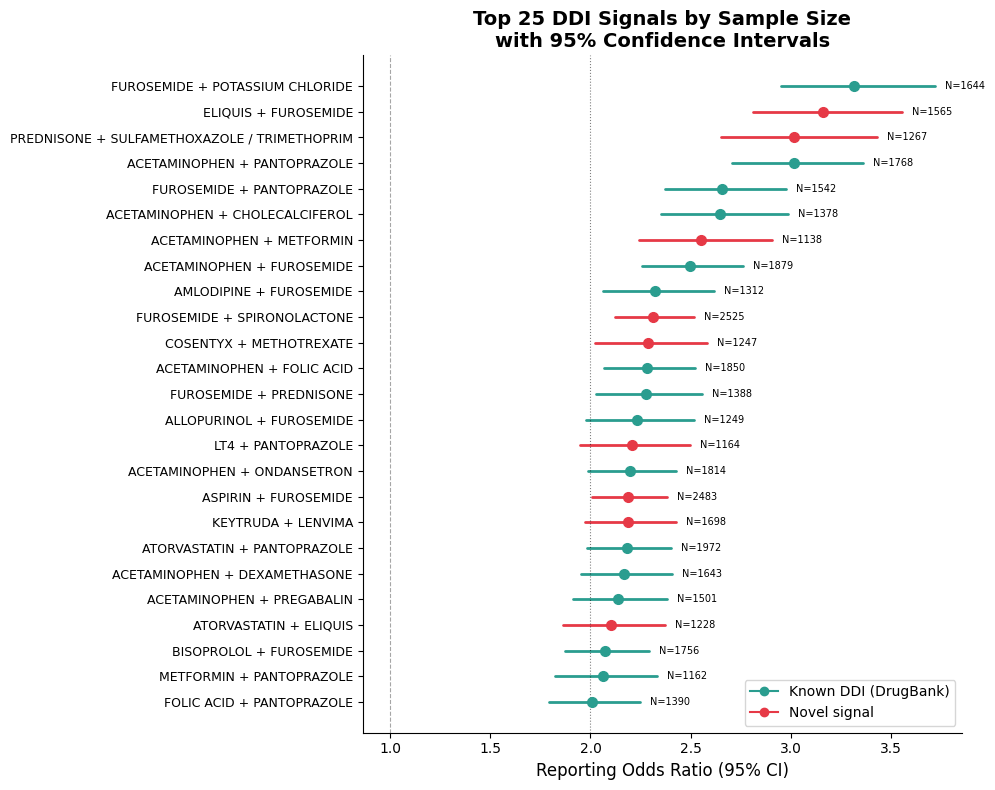

Known DDIs: 16
Novel signals: 9

Breakdown:
  KNOWN: FOLIC ACID + PANTOPRAZOLE
  KNOWN: METFORMIN + PANTOPRAZOLE
  KNOWN: BISOPROLOL + FUROSEMIDE
  NOVEL: ATORVASTATIN + ELIQUIS
  KNOWN: ACETAMINOPHEN + PREGABALIN
  KNOWN: ACETAMINOPHEN + DEXAMETHASONE
  KNOWN: ATORVASTATIN + PANTOPRAZOLE
  NOVEL: KEYTRUDA + LENVIMA
  NOVEL: ASPIRIN + FUROSEMIDE
  KNOWN: ACETAMINOPHEN + ONDANSETRON
  NOVEL: LT4 + PANTOPRAZOLE
  KNOWN: ALLOPURINOL + FUROSEMIDE
  KNOWN: FUROSEMIDE + PREDNISONE
  KNOWN: ACETAMINOPHEN + FOLIC ACID
  NOVEL: COSENTYX + METHOTREXATE
  NOVEL: FUROSEMIDE + SPIRONOLACTONE
  KNOWN: AMLODIPINE + FUROSEMIDE
  KNOWN: ACETAMINOPHEN + FUROSEMIDE
  NOVEL: ACETAMINOPHEN + METFORMIN
  KNOWN: ACETAMINOPHEN + CHOLECALCIFEROL
  KNOWN: FUROSEMIDE + PANTOPRAZOLE
  KNOWN: ACETAMINOPHEN + PANTOPRAZOLE
  NOVEL: PREDNISONE + SULFAMETHOXAZOLE / TRIMETHOPRIM
  NOVEL: ELIQUIS + FUROSEMIDE
  KNOWN: FUROSEMIDE + POTASSIUM CHLORIDE

Saved: fig3c_forest_plot_drugbank.png


In [26]:
# ============================================================
# FIGURE 3c: Forest Plot — DrugBank-matched Known/Novel
# ============================================================

drugbank = pd.read_csv("DRUGBANK_DDI_REFERENCE.csv")
drugbank_pairs = set(drugbank['PAIR'])

top25 = hc.nlargest(25, 'N_EXPOSED').copy()

# Component-level matching (same logic as your pipeline)
# Strip salt forms and check both orderings
def strip_salt(name):
    for suffix in [' HYDROCHLORIDE', ' SODIUM', ' SULFATE', ' MALEATE', ' FUMARATE',
                   ' ACETATE', ' MESYLATE', ' POTASSIUM', ' CALCIUM', ' TARTRATE',
                   ' BESYLATE', ' SUCCINATE', ' PHOSPHATE', ' CITRATE', ' BROMIDE',
                   ' CHLORIDE', ' NITRATE', ' OXIDE', ' LACTATE']:
        name = name.replace(suffix, '')
    return name.strip()

def check_drugbank(pair):
    if pair in drugbank_pairs:
        return True
    # Try stripped versions
    parts = pair.split(' + ')
    if len(parts) == 2:
        a, b = strip_salt(parts[0]), strip_salt(parts[1])
        combos = [f"{a} + {b}", f"{b} + {a}"]
        for c in combos:
            if c in drugbank_pairs:
                return True
        # Also check original names in swapped order
        swap = f"{parts[1]} + {parts[0]}"
        if swap in drugbank_pairs:
            return True
    return False

top25['known'] = top25['PAIR'].apply(check_drugbank)
top25 = top25.sort_values('ROR', ascending=True)

# Clean labels
top25['label'] = top25['DRUG_A'] + ' + ' + top25['DRUG_B']
top25['label'] = top25['label'].str.replace(' HYDROCHLORIDE', '', regex=False)
top25['label'] = top25['label'].str.replace(' SODIUM', '', regex=False)
top25['label'] = top25['label'].str.replace(' SULFATE', '', regex=False)

colors = ['#2A9D8F' if k else '#E63946' for k in top25['known']]

fig, ax = plt.subplots(figsize=(10, 8))

for i, (_, row) in enumerate(top25.iterrows()):
    color = colors[i]
    ax.plot([row['CI_LOWER'], row['CI_UPPER']], [i, i], color=color, linewidth=2, solid_capstyle='round')
    ax.plot(row['ROR'], i, 'o', color=color, markersize=7, zorder=5)

ax.axvline(1, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
ax.axvline(2, color='black', linestyle=':', linewidth=0.8, alpha=0.5)

ax.set_yticks(range(len(top25)))
ax.set_yticklabels(top25['label'], fontsize=9)
ax.set_xlabel('Reporting Odds Ratio (95% CI)', fontsize=12)
ax.set_title('Top 25 DDI Signals by Sample Size\nwith 95% Confidence Intervals', fontsize=14, fontweight='bold')

for i, (_, row) in enumerate(top25.iterrows()):
    ax.text(row['CI_UPPER'] + 0.05, i, f"N={int(row['N_EXPOSED'])}", fontsize=7, va='center')

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='#2A9D8F', marker='o', linestyle='-', label='Known DDI (DrugBank)'),
    Line2D([0], [0], color='#E63946', marker='o', linestyle='-', label='Novel signal'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

sns.despine()
plt.tight_layout()
plt.savefig('fig3c_forest_plot_drugbank.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Known DDIs: {top25['known'].sum()}")
print(f"Novel signals: {(~top25['known']).sum()}")
print("\nBreakdown:")
for _, row in top25.iterrows():
    status = "KNOWN" if row['known'] else "NOVEL"
    print(f"  {status}: {row['PAIR']}")
print("\nSaved: fig3c_forest_plot_drugbank.png")